#### import data

In [2]:
import pandas as pd
# import data
# import kagglehub

# path = kagglehub.train_set_download("stealthtechnologies/employee-attrition-train_set")
# train_set = pd.read_csv(path+"/train.csv")
# test_set = pd.read_csv(path+"/test.csv")
train_set = pd.read_csv('data/train.csv')
test_set = pd.read_csv('data/test.csv')
# drop id
train_set.drop('Employee ID', axis=1, inplace=True)
test_set.drop('Employee ID', axis=1, inplace=True)
# train_set = pd.concat([train_set, test_set], axis=0, ignore_index=True)
# train_set.head()

In [3]:
print(train_set.info())
print(train_set.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       59598 non-null  int64 
 1   Gender                    59598 non-null  object
 2   Years at Company          59598 non-null  int64 
 3   Job Role                  59598 non-null  object
 4   Monthly Income            59598 non-null  int64 
 5   Work-Life Balance         59598 non-null  object
 6   Job Satisfaction          59598 non-null  object
 7   Performance Rating        59598 non-null  object
 8   Number of Promotions      59598 non-null  int64 
 9   Overtime                  59598 non-null  object
 10  Distance from Home        59598 non-null  int64 
 11  Education Level           59598 non-null  object
 12  Marital Status            59598 non-null  object
 13  Number of Dependents      59598 non-null  int64 
 14  Job Level             

get unordinal and ordinal features

In [4]:
ordinal_features = set(['Gender', 'Attrition', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Education Level', 'Job Level', 'Company Size', 'Company Reputation', 'Employee Recognition',])
unordinal_features = set(train_set.select_dtypes(include=['object']).columns) - ordinal_features

# print unique values of ordinal features
for feature in ordinal_features:
    print(f"{feature}: {train_set[feature].unique()}")

Employee Recognition: ['Medium' 'Low' 'High' 'Very High']
Education Level: ['Associate Degree' 'Master’s Degree' 'Bachelor’s Degree' 'High School'
 'PhD']
Company Size: ['Medium' 'Small' 'Large']
Job Satisfaction: ['Medium' 'High' 'Very High' 'Low']
Job Level: ['Mid' 'Senior' 'Entry']
Gender: ['Male' 'Female']
Performance Rating: ['Average' 'Low' 'High' 'Below Average']
Attrition: ['Stayed' 'Left']
Work-Life Balance: ['Excellent' 'Poor' 'Good' 'Fair']
Company Reputation: ['Excellent' 'Fair' 'Poor' 'Good']


In [5]:
# ordinal features
dict_ordinal = {
    'Gender': {'Male': 0, 'Female': 1},
    'Employee Recognition': {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3},
    'Company Size': {'Small': 0, 'Medium': 1, 'Large': 2},
    'Job Satisfaction': {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3},
    'Performance Rating': {'Low': 0, 'Below Average': 1, 'Average': 2, 'High': 3},
    'Company Reputation': {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3},
    'Education Level': {'High School': 0, 'Associate Degree': 1, 'Bachelor’s Degree': 2, 'Master’s Degree': 3, 'PhD': 4},
    'Job Level': {'Entry': 0, 'Mid': 1, 'Senior': 2},
    'Work-Life Balance': {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3},
    'Attrition': {'Left': 0, 'Stayed': 1}
}
for feature in ordinal_features:
    train_set[feature] = train_set[feature].map(dict_ordinal[feature])
    test_set[feature] = test_set[feature].map(dict_ordinal[feature])

# unordinal features
for column in unordinal_features:
    train_set= train_set.join(pd.get_dummies(train_set[column], prefix=column))
    train_set.drop(labels=column, axis=1, inplace=True)
    test_set = test_set.join(pd.get_dummies(test_set[column], prefix=column))
    test_set.drop(labels=column, axis=1, inplace=True)


In [6]:
print(train_set.info())
print(train_set.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Age                           59598 non-null  int64
 1   Gender                        59598 non-null  int64
 2   Years at Company              59598 non-null  int64
 3   Monthly Income                59598 non-null  int64
 4   Work-Life Balance             59598 non-null  int64
 5   Job Satisfaction              59598 non-null  int64
 6   Performance Rating            59598 non-null  int64
 7   Number of Promotions          59598 non-null  int64
 8   Distance from Home            59598 non-null  int64
 9   Education Level               59598 non-null  int64
 10  Number of Dependents          59598 non-null  int64
 11  Job Level                     59598 non-null  int64
 12  Company Size                  59598 non-null  int64
 13  Company Tenure                5

Attrition
1    0.524514
0    0.475486
Name: count, dtype: float64


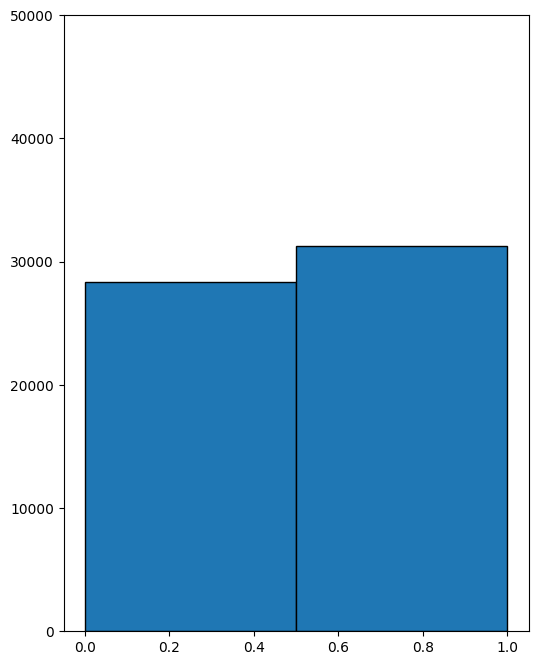

In [7]:
import matplotlib.pyplot as plt

print(train_set['Attrition'].value_counts() / train_set['Attrition'].count())
plt.figure(figsize=(6, 8))
plt.ylim(0, 50000)
plt.hist(train_set['Attrition'], bins=(2), edgecolor='black')
plt.show()

In [8]:
# from sklearn.preprocessing  import StandardScaler, MinMaxScaler
# sc = StandardScaler()
# mc = MinMaxScaler()
# # scale ordinal features
# train_set[list(ordinal_features - {'Gender', 'Attrition'})] = mc.fit_transform(train_set[list(ordinal_features - {'Gender', 'Attrition'})])
# test_set[list(ordinal_features - {'Gender', 'Attrition'})] = mc.transform(test_set[list(ordinal_features - {'Gender', 'Attrition'})])
# # scale continous features
# train_set[['Years at Company', 'Monthly Income', 'Distance from Home', 'Age', 'Number of Promotions', 'Number of Dependents']] = sc.fit_transform(train_set[['Years at Company', 'Monthly Income', 'Distance from Home', 'Age', 'Number of Promotions', 'Number of Dependents']])
# test_set[['Years at Company', 'Monthly Income', 'Distance from Home', 'Age', 'Number of Promotions', 'Number of Dependents']] = sc.transform(test_set[['Years at Company', 'Monthly Income', 'Distance from Home', 'Age', 'Number of Promotions', 'Number of Dependents']])
train_set.to_csv('train_processed.csv', index=False)
test_set.to_csv('test_processed.csv', index=False)

In [9]:
print(train_set["Attrition"])

0        1
1        1
2        1
3        1
4        1
        ..
59593    0
59594    0
59595    1
59596    0
59597    1
Name: Attrition, Length: 59598, dtype: int64
